In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from models import train_linear_model, train_logistic_model
from sklearn.metrics import accuracy_score

# Load dataset
relative_path = "data/student_portugal/student_mat_processed.csv"
data_file = os.path.join(os.getcwd(), relative_path)
df = pd.read_csv(data_file)
print("Loaded datafile")

# Ensure all rows are unique
df = df.drop_duplicates()
print("Removed duplicate rows")

# Split into training and testing sets (85% training, 15% testing)
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)
print("Data split into training and testing sets")

Using device: cpu
Loaded datafile
Removed duplicate rows
Data split into training and testing sets


In [2]:
from data import get_relative_csv_data, remove_constant_columns
relative_path = "data/test.csv"
df = get_relative_csv_data(relative_path)
df = remove_constant_columns(df)
df


,first,"""second""","""fourth""","""fifth"""
0,1,2,4,5
1,5,4,2,1
2,1,2,4,5
3,1,2,4,5
4,1,2,4,5
5,1,2,4,5
6,1,2,4,5
7,1,2,4,5
8,1,2,4,5
9,1,2,4,5


In [3]:
from data import remove_outliers_all_columns
df = remove_outliers_all_columns(df)
df

,first,"""second""","""fourth""","""fifth"""
0,1,2,4,5
2,1,2,4,5
3,1,2,4,5
4,1,2,4,5
5,1,2,4,5
6,1,2,4,5
7,1,2,4,5
8,1,2,4,5
9,1,2,4,5
10,1,2,4,5


In [4]:

# Define features and target variable
X_train = train_df.drop(columns=['failures']).values
y_train_reg = train_df['failures']
y_train_cls = (train_df['failures'] > 0).astype(int)

X_test = test_df.drop(columns=['failures']).values
y_test_reg = test_df['failures']
y_test_cls = (test_df['failures'] > 0).astype(int)

regularizer_weight = 0.01  # Regularization strength

print("Classifier identified")


Classifier identified


In [5]:
X_train

array([[0, 1, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 1],
       [0, 1, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]], shape=(296, 44))

In [6]:
y_train_reg

16     0
66     0
211    0
7      0
19     0
      ..
71     0
106    0
270    2
348    0
102    0
Name: failures, Length: 296, dtype: int64

In [7]:

# Train regression models
print("Training RegN")
model1 = train_linear_model(X_train, y_train_reg.values, reg_type=None)  # Standard
print("Training Reg1")
model2 = train_linear_model(X_train, y_train_reg.values, reg_type="l1", alpha=regularizer_weight)  # Lasso
print("Training Reg2")
model3 = train_linear_model(X_train, y_train_reg.values, reg_type="l2", alpha=regularizer_weight)  # Ridge

# Train logistic models
print("Training LogN")
model4 = train_logistic_model(X_train, y_train_cls.values, reg_type=None)  # Standard
print("Training Log1")
model5 = train_logistic_model(X_train, y_train_cls.values, reg_type="l1", alpha=regularizer_weight)  # Lasso
print("Training Log2")
model6 = train_logistic_model(X_train, y_train_cls.values, reg_type="l2", alpha=regularizer_weight)  # Ridge


Training RegN
Training Reg1


Training Reg2
Training LogN
Training Log1
Training Log2


Evaluating models
Regression Models:


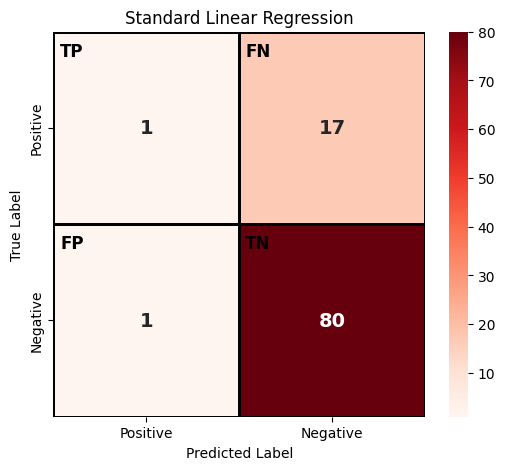

Standard Linear Regression accuracy: 0.8181818181818182
Standard Linear Regression f1 score: 0.09999999999999999


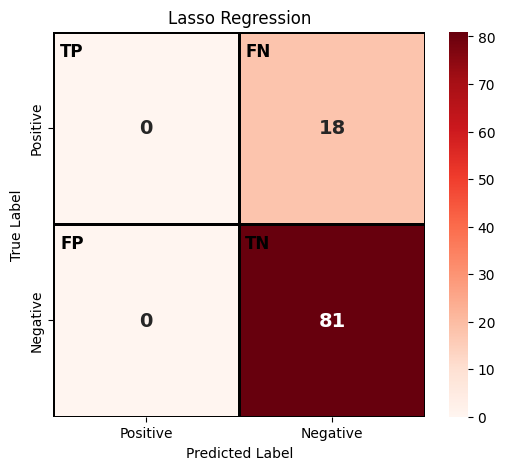

Lasso Regression accuracy: 0.8181818181818182
Lasso Regression f1 score: 0


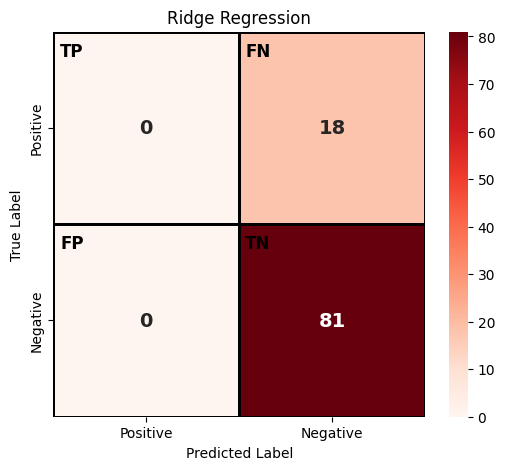

Ridge Regression accuracy: 0.8181818181818182
Ridge Regression f1 score: 0
Logistic Models:


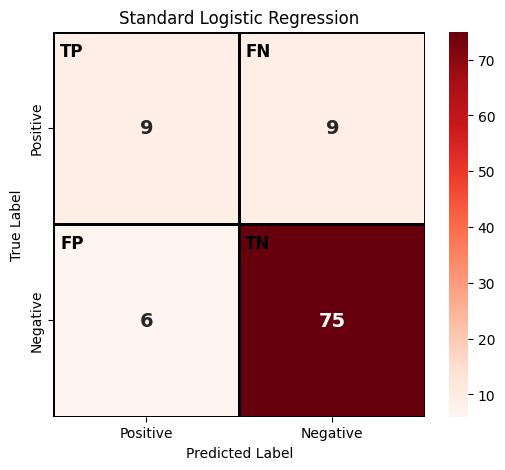

Standard Logistic Regression accuracy: 0.8484848484848485
Standard Logistic Regression f1 score: 0.5454545454545454


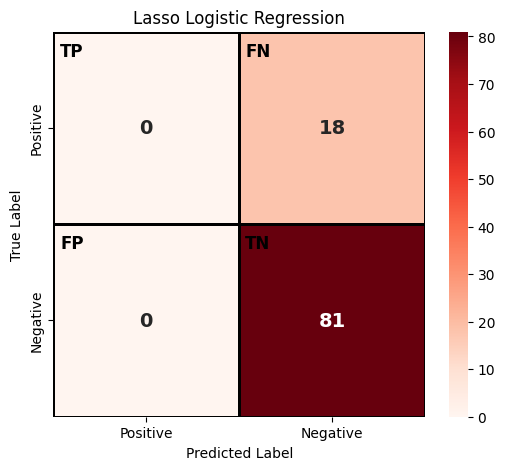

Lasso Logistic Regression accuracy: 0.8181818181818182
Lasso Logistic Regression f1 score: 0


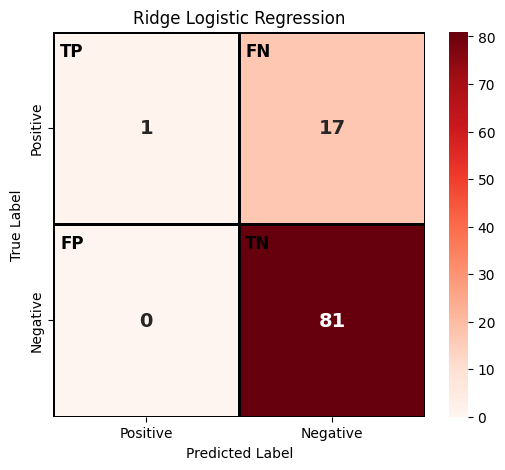

Ridge Logistic Regression accuracy: 0.8282828282828283
Ridge Logistic Regression f1 score: 0.10526315789473684


In [8]:
from evaluation import plot_confusion_matrix, fscore
# Testing Section
print("Evaluating models")

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test) > 0
    acc = accuracy_score(y_test, y_pred)
    f1 = fscore(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred, model_name)
    print(f"{model_name} accuracy: {acc}")
    print(f"{model_name} f1 score: {f1}")
    

# Evaluate regression models
print("Regression Models:")
evaluate_model(model1, X_test, (y_test_reg > 0).astype(int), "Standard Linear Regression")
evaluate_model(model2, X_test, (y_test_reg > 0).astype(int), "Lasso Regression")
evaluate_model(model3, X_test, (y_test_reg > 0).astype(int), "Ridge Regression")

# Evaluate logistic models
print("Logistic Models:")
evaluate_model(model4, X_test, y_test_cls, "Standard Logistic Regression")
evaluate_model(model5, X_test, y_test_cls, "Lasso Logistic Regression")
evaluate_model(model6, X_test, y_test_cls, "Ridge Logistic Regression")

